# Network training pipeline
This notebook implements a complete PyTorch-based framework for training deep neural networks to estimate robotic joint torques ($\tau$) based on state variables ($q, \dot{q}, \ddot{q}$).


*   Automates the loading of data from Google Drive, dynamically extracting Degrees of Freedom (DOF) from directory structures to initialize the PklDataset.
*  Includes optional trigonometric encoding, mapping joint positions $q$ to $(\sin(q), \cos(q))$
*  Defines multiple Multi-Layer Perceptron (MLP) configurations (Net, DeepNet, DeeperNet) ranging from 2 to 7 hidden layers with ReLU activations.
* Utilizes the Adam optimizer with a normalized MSE loss function to perform network training



# IMPORT AND CONNECTION TO DRIVE

---






In [ ]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import glob
import os
import random
import torch
import re # regular expressions


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [ ]:
from google.colab import drive

In [ ]:
# drive.flush_and_unmount()

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/NNDL_PROGETTO/data_generation/2dof/"

test_data  train_data  val_data


# NETWORK DEFINITION
---

In [ ]:
class Net(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        print('Network initialized')

        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.out = nn.Linear(Nh2, No)
        self.act = nn.ReLU()

    def forward(self, x, additional_out=False):

        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x)

        return x

In [ ]:
class DeepNet(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, Nh3, Nh4, Nh5, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()


        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.fc3 = nn.Linear(Nh2, Nh3)
        self.fc4 = nn.Linear(Nh3, Nh4)
        self.fc5 = nn.Linear(Nh4, Nh5)
        self.out = nn.Linear(Nh5, No)

        self.act = nn.ReLU()


    def forward(self, x, additional_out=False):

        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        x = self.act(self.fc5(x))
        x = self.out(x)
        return x


In [ ]:
class DeeperNet(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, Nh3, Nh4, Nh5, Nh6, Nh7, No):
        """
        Ni  - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        Nh3 - Neurons in the 3rd hidden layer
        Nh4 - Neurons in the 4th hidden layer
        Nh5 - Neurons in the 5th hidden layer
        No  - Output size
        """
        super().__init__()

        print('Network initialized')
        ###################################################
        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.fc3 = nn.Linear(Nh2, Nh3)
        self.fc4 = nn.Linear(Nh3, Nh4)
        self.fc5 = nn.Linear(Nh4, Nh5)
        self.fc6 = nn.Linear(Nh5, Nh6)
        self.fc7 = nn.Linear(Nh6, Nh7)
        self.out = nn.Linear(Nh7, No)

        self.act = nn.ReLU()
        ###################################################

    def forward(self, x, additional_out=False):
        ###################################################
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        x = self.act(self.fc5(x))
        x = self.act(self.fc6(x))
        x = self.act(self.fc7(x))
        x = self.out(x)
        return x
        ###################################################

# PKL DATASET CLASS DEFINITION
---



In [ ]:
import re
import glob
import os
import pandas as pd
import numpy as np
import random
from torch.utils.data import Dataset

class PklDataset(Dataset):
    """
    Dataset class to load and process robotic state data from pickle files.
    Expected data includes joint positions (q), velocities (dq),
    accelerations (ddq), and noiseless torques (tau).
    """
    def __init__(self, pkl_folder, random_choice=False, transform=None, normalize_y=False, conv_sin_cos=False):
        self.transform = transform
        self.normalize_y = normalize_y
        self.conv_sin_cos = conv_sin_cos

        # Extract Degrees of Freedom (DOF) from folder name using regex
        match = re.search(r"(\d+)dof", pkl_folder)
        if not match:
            raise ValueError(f"Unable to extract DOF from folder name: {pkl_folder}")
        self.n_dof = int(match.group(1))

        # Generate column names based on DOFn
        columns = [f"{prefix}_{j}" for j in range(1, self.n_dof+1) for prefix in ("q", "dq", "ddq")]
        columns += [f"tau_noiseless_{j}" for j in range(1, self.n_dof+1)]

        # Retrieve all pickle files in the specified directory
        pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))
        X_list, Y_list = [], []

        # Load data: either all files or a single random file
        if not random_choice:
            for file_path in pkl_files:
                df = pd.read_pickle(file_path)
                np_array = df[columns].to_numpy()
                # Split features (q, dq, ddq) from targets (tau)
                X_list.append(np_array[:, :(3*self.n_dof)])
                Y_list.append(np_array[:, (3*self.n_dof):])
        else:
            file_path = random.choice(pkl_files)
            df = pd.read_pickle(file_path)
            np_array = df[columns].to_numpy()
            X_list.append(np_array[:, :(3*self.n_dof)])
            Y_list.append(np_array[:, (3*self.n_dof):])

        # Concatenate all loaded data into single numpy arrays
        self.X = np.vstack(X_list)
        self.Y = np.vstack(Y_list)

        # Compute statistics for Y normalization (mean and standard deviation)
        self.mean_y = np.mean(self.Y, axis=0)
        self.std_y = np.std(self.Y, axis=0)
        # Prevent division by zero by setting zero-std to 1
        self.std_y[self.std_y == 0] = 1

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x, y = self.X[idx], self.Y[idx]

        # Trigonometric encoding for joint positions: maps q -> [sin(q), cos(q)]
        if self.conv_sin_cos:
            q   = x[0::3]       # Extract q components
            dq  = x[1::3]       # Extract dq components
            ddq = x[2::3]       # Extract ddq components

            # Efficiently build the output array: shape (4 * n_dof,)
            x_out = np.empty(4 * self.n_dof, dtype=np.float32)
            x_out[0::4] = np.sin(q)
            x_out[1::4] = np.cos(q)
            x_out[2::4] = dq
            x_out[3::4] = ddq
        else:
            x_out = x.astype(np.float32)

        y_out = y.astype(np.float32)

        # Apply normalization to the output targets if enabled
        if self.normalize_y:
            y_out = (y_out - self.mean_y) / self.std_y

        sample = (x_out, y_out)

        # Apply external transformations
        if self.transform:
            sample = self.transform(sample)

        return sample

# Transform
---


In [ ]:
class ToTensor(object):
    """Convert numpy arrays to torch tensors."""
    def __call__(self, sample):
        import torch
        x, y = sample
        return (torch.from_numpy(x).float(), torch.from_numpy(y).float())


# Training parameters
---

In [ ]:
n_dof = 7
net_type = "shallow_network"
conv_sin_cos = True
composed_transform = transforms.Compose([ToTensor()])

In [ ]:
train_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/train_data/', transform=composed_transform, normalize_y=True, conv_sin_cos=conv_sin_cos)
val_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/val_data/', transform=composed_transform, conv_sin_cos=conv_sin_cos)
test_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/test_data/', transform=composed_transform, conv_sin_cos=conv_sin_cos)

In [ ]:
print(train_dataset.mean_y)
print(train_dataset.std_y)

print(val_dataset.mean_y)
print(val_dataset.std_y)

print(test_dataset.mean_y)
print(test_dataset.std_y)

[ 8.67170465e-05 -1.33095930e+01 -7.05890699e-02  1.37537737e+01
  3.52697114e-01  7.41195041e-01  1.21108745e-03]
[ 4.44604269 22.11200397  8.81719514  6.00121939  0.63659782  0.85582398
  0.05492794]
[ 2.05023332e-04 -1.30247430e+01 -5.11165717e-01  1.34147607e+01
  3.36967064e-01  6.32569407e-01  1.95139042e-04]
[ 4.32657771 22.46127114  8.73061005  6.13208865  0.65253765  0.89121887
  0.05567152]
[ 1.39006546e-04 -1.22475974e+01  4.18307105e-02  1.34907835e+01
  3.50718909e-01  7.32981391e-01  2.64923280e-03]
[ 4.48113049 22.38776326  8.88503881  6.31706071  0.64606592  0.85744426
  0.05507407]


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_dataloader  = DataLoader(val_dataset,  batch_size=64, shuffle=False, num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

In [ ]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cuda


In [ ]:
if net_type == "shallow_network":
  # Initialize the network
  torch.manual_seed(0)
  if not conv_sin_cos:
    Ni = (3*train_dataset.n_dof)
  else:
    Ni = (4*train_dataset.n_dof)
  Nh1 = 128
  Nh2 = 256
  No = train_dataset.n_dof
  net = Net(Ni, Nh1, Nh2, No)
  net.to(device)
  print(f"{net_type} created")
elif net_type == "deep_network":
  # Initialize the network
  torch.manual_seed(0)
  if not conv_sin_cos:
    Ni = (3*train_dataset.n_dof)
  else:
    Ni = (4*train_dataset.n_dof)
  Nh1 = 128
  Nh2 = 256
  Nh3 = 256
  Nh4 = 256
  Nh5 = 128
  No = train_dataset.n_dof
  net = DeepNet(Ni, Nh1, Nh2, Nh3, Nh4, Nh5, No)
  net.to(device)
  print(f"{net_type} created")
else:
  print("Network type not recognized")

Network initialized
shallow_network created


# Definition of nMSE loss function

In [ ]:
# Define the loss function
loss_fn = nn.MSELoss()

def mse_per_joint(pred, target):
    criterion = nn.MSELoss(reduction='none')
    loss = criterion(pred, target).mean(dim = 0)
    # shape: (batch_size,n_joints).mean(lungo batch size) -> (n_joints)
    return loss

def nmse_per_joint(pred, target, std_dev, eps=1e-8):
    return mse_per_joint(pred, target) / (std_dev**2 + eps)

In [ ]:
# Define the optimizer
optimizer = optim.Adam(net.parameters(), lr=1e-3)

# Training the network

In [ ]:
num_epochs = 50
epochs_checkpoint = 0

# Training log lists
train_loss_log = []
train_loss_joints_log = []
train_loss_nmse_log = []
train_loss_nmse_per_joint_log = []

# Validation log lists
val_loss_log = []
val_loss_joints_log = []
val_loss_nmse_log = []
val_loss_nmse_per_joint_log = []

# Converting means and stdev to tensor
train_mean_tensor = torch.tensor(train_dataset.mean_y, dtype=torch.float32, device=device)
train_std_tensor = torch.tensor(train_dataset.std_y, dtype=torch.float32, device=device)
val_std_tensor = torch.tensor(val_dataset.std_y, dtype=torch.float32, device=device)

for epoch_num in range(num_epochs):
    print('#################')
    print(f'# EPOCH {epoch_num}')
    print('#################')

    if epoch_num % 10 == 0 and epoch_num != 0:
      checkpoint = {
          "epoch": epoch_num,
          "model_state_dict": net.state_dict(),
          "optimizer_state_dict": optimizer.state_dict(),
          "train_loss_log": list(train_loss_log),
          "val_loss_log": list(val_loss_log),
          "train_loss_nmse_log": list(train_loss_nmse_log),
          "val_loss_nmse_log": list(val_loss_nmse_log),
          "train_loss_joints_log": list(train_loss_joints_log),
          "val_loss_joints_log": list(val_loss_joints_log),
          "train_loss_nmse_per_joint_log": list(train_loss_nmse_per_joint_log),
          "val_loss_nmse_per_joint_log": list(val_loss_nmse_per_joint_log)
      }

      torch.save(checkpoint, f'/content/drive/MyDrive/NNDL_PROGETTO/models_DELAN/{n_dof}dof/checkpoint_epoch{epoch_num}.pt')
      print(f"Checkpoint salvato a epoca {epoch_num}")


    ### TRAIN

    # Lists containing the losses of the i-th epoch
    train_loss= []
    train_loss_nmse= []
    train_loss_nmse_per_joint = []
    train_loss_joints = []

    net.train()
    for sample_batched in train_dataloader:
        x_batch = sample_batched[0].to(device)
        label_batch = sample_batched[1].to(device)

        # Forward pass
        out = net(x_batch)
        loss = loss_fn(out, label_batch)

        # Compute loss and save
        with torch.no_grad():
          out_denorm = out * train_std_tensor + train_mean_tensor
          label_denorm = label_batch * train_std_tensor + train_mean_tensor
          loss_nmse_per_joint = nmse_per_joint(out_denorm, label_denorm, train_std_tensor)
          loss_nmse = torch.mean(loss_nmse_per_joint.cpu())
          loss_per_joint = mse_per_joint(out_denorm, label_denorm)
          loss_mse = loss_fn(out_denorm, label_denorm)

        # Backpropagation
        net.zero_grad()
        loss.backward()

        # Update the weights
        optimizer.step()

        # Save train loss for this batch and also for each joints
        loss_batch = loss_mse.detach().cpu().numpy()
        train_loss.append(loss_batch)

        loss_batch_joints = loss_per_joint.cpu().numpy()
        train_loss_joints.append(loss_batch_joints)

        loss_batch_nmse = loss_nmse.cpu().numpy()
        train_loss_nmse.append(loss_batch_nmse)

        loss_batch_nmse_per_joint = loss_nmse_per_joint.cpu().numpy()
        train_loss_nmse_per_joint.append(loss_batch_nmse_per_joint)


    # Save average train loss per epoch
    train_loss = np.mean(train_loss)
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    train_loss_joints = np.mean(np.vstack(train_loss_joints), axis=0)
    print(f"TRAIN LOSS PER JOINT: {train_loss_joints}")
    train_loss_nmse = np.mean(train_loss_nmse)
    print(f"AVERAGE TRAIN NMSE: {train_loss_nmse}")
    train_loss_nmse_per_joint = np.mean(np.vstack(train_loss_nmse_per_joint), axis=0)
    print(f"TRAIN NMSE PER JOINT: {train_loss_nmse_per_joint}")

    # Update training log vectors
    train_loss_log.append(train_loss)
    train_loss_joints_log.append(train_loss_joints)
    train_loss_nmse_log.append(train_loss_nmse)
    train_loss_nmse_per_joint_log.append(train_loss_nmse_per_joint)

    ### VALIDATION
    val_loss= []
    val_loss_joints = []
    val_loss_nmse= []
    val_loss_nmse_per_joint = []
    net.eval()
    with torch.no_grad():
        for sample_batched in val_dataloader:
            x_batch = sample_batched[0].to(device)
            label_batch = sample_batched[1].to(device)

            # Forward pass
            out = net(x_batch)

            out = out * train_std_tensor + train_mean_tensor

            # Compute loss
            loss = loss_fn(out, label_batch)
            loss_nmse_per_joint = nmse_per_joint(out, label_batch, val_std_tensor)
            loss_nmse = torch.mean(loss_nmse_per_joint)
            loss_per_joint = mse_per_joint(out, label_batch)

            # Save val loss for this batch
            loss_batch = loss.cpu().numpy()
            val_loss.append(loss_batch)

            loss_batch_joints = loss_per_joint.cpu().numpy()
            val_loss_joints.append(loss_batch_joints)

            loss_batch_nmse = loss_nmse.cpu().numpy()
            val_loss_nmse.append(loss_batch_nmse)

            loss_batch_nmse_per_joint = loss_nmse_per_joint.cpu().numpy()
            val_loss_nmse_per_joint.append(loss_batch_nmse_per_joint)


        # Save average validation loss
        val_loss = np.mean(val_loss)
        print(f"AVERAGE VAL LOSS: {val_loss}")
        val_loss_log.append(val_loss)

        val_loss_joints = np.mean(np.vstack(val_loss_joints), axis=0)
        print(f"VAL LOSS JOINTS: {val_loss_joints}")
        val_loss_joints_log.append(val_loss_joints)

        val_loss_nmse = np.mean(val_loss_nmse)
        print(f"AVERAGE VAL NMSE: {val_loss_nmse}")
        val_loss_nmse_log.append(val_loss_nmse)

        val_loss_nmse_per_joint = np.mean(np.vstack(val_loss_nmse_per_joint), axis=0)
        print(f"VAL NMSE PER JOINT: {val_loss_nmse_per_joint}")
        val_loss_nmse_per_joint_log.append(val_loss_nmse_per_joint)

        if epoch_num == num_epochs-1:
          checkpoint = {
              "epoch": epoch_num,
              "model_state_dict": net.state_dict(),
              "optimizer_state_dict": optimizer.state_dict(),
              "train_loss_log": list(train_loss_log), # copia
              "val_loss_log": list(val_loss_log),
              "train_loss_nmse_log": list(train_loss_nmse_log), # copia
              "val_loss_nmse_log": list(val_loss_nmse_log),
              "train_loss_joints_log": list(train_loss_joints_log),
              "val_loss_joints_log": list(val_loss_joints_log),
              "train_loss_nmse_per_joint_log": list(train_loss_nmse_per_joint_log),
              "val_loss_nmse_per_joint_log": list(val_loss_nmse_per_joint_log)
          }

          torch.save(checkpoint, f'/content/drive/MyDrive/NNDL_PROGETTO/models_sin_cos/{net_type}/{n_dof}dof/checkpoint_epoch{epoch_num+1}.pt')
          print(f"Checkpoint salvato a epoca {epoch_num+1}")

#################
# EPOCH 0
#################
AVERAGE TRAIN LOSS: 0.005187178496271372
TRAIN LOSS PER JOINT: [0.0070773  0.00192403 0.00330112 0.00440883 0.00547098 0.00554738
 0.00858056]
AVERAGE TRAIN NMSE: 0.40937021374702454
TRAIN NMSE PER JOINT: [3.5803186e-04 3.9351085e-06 4.2462059e-05 1.2241772e-04 1.3500041e-02
 7.5739021e-03 2.8439879e+00]
AVERAGE VAL LOSS: 0.4837259352207184
VAL LOSS JOINTS: [4.0606192e-01 1.9309245e+00 6.2151402e-01 4.0023813e-01 1.0809563e-02
 1.6405521e-02 1.2487329e-04]
AVERAGE VAL NMSE: 0.018664095550775528
VAL NMSE PER JOINT: [0.02169217 0.00382734 0.00815384 0.01064392 0.02538616 0.02065479
 0.04029041]
#################
# EPOCH 1
#################
AVERAGE TRAIN LOSS: 0.0050266156904399395
TRAIN LOSS PER JOINT: [0.00682233 0.00190546 0.0032569  0.00428515 0.00529124 0.00536772
 0.0082575 ]
AVERAGE TRAIN NMSE: 0.3939721882343292
TRAIN NMSE PER JOINT: [3.4513310e-04 3.8971193e-06 4.1893127e-05 1.1898396e-04 1.3056500e-02
 7.3285955e-03 2.7369151e+00]
AV

# Plotting training and validation losses

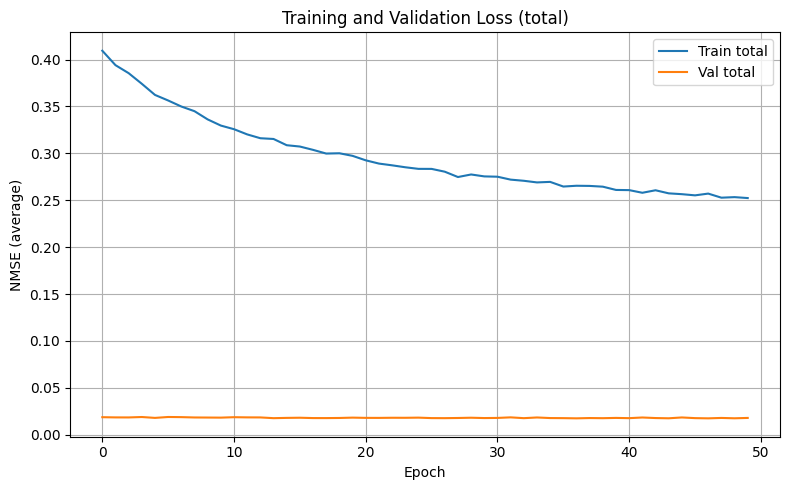

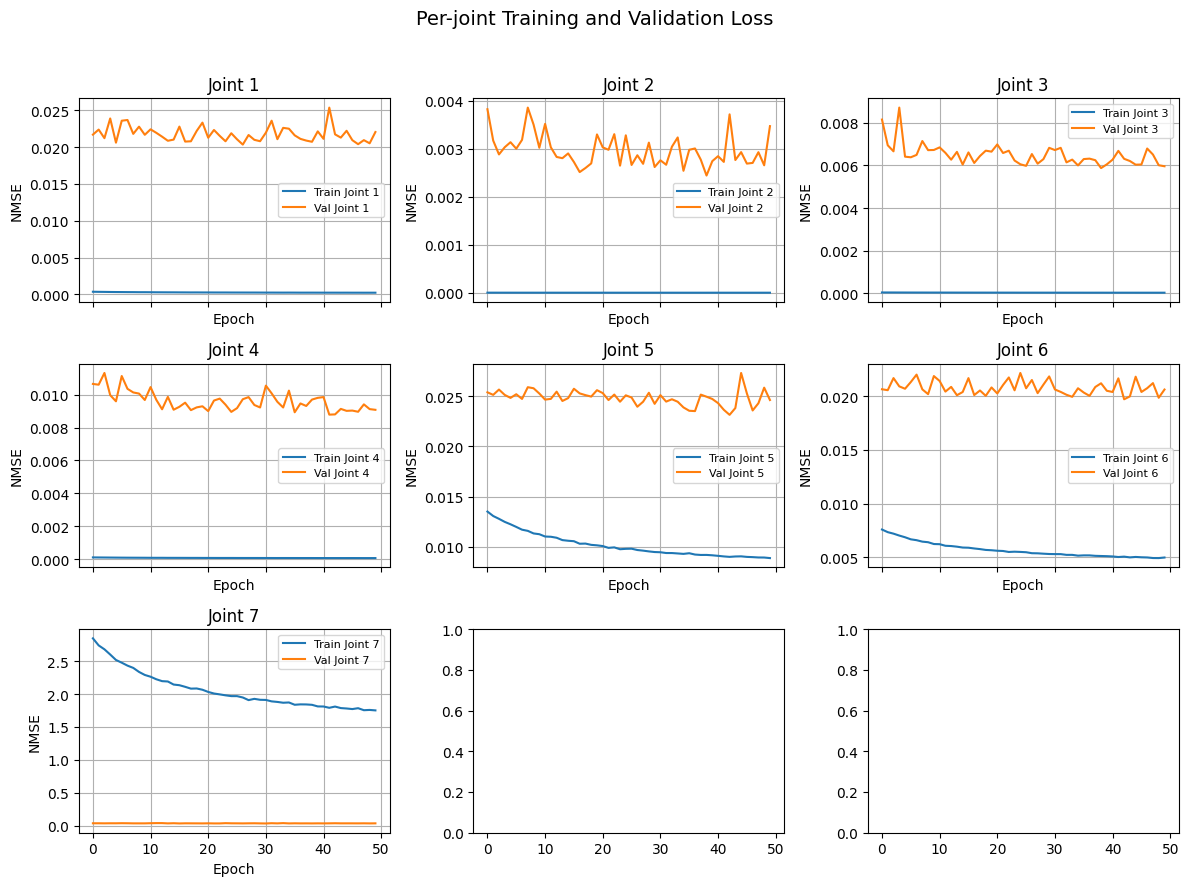

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Convertion to numpy array
train_loss_nmse_log = np.array(train_loss_nmse_log)                     # (epochs,)
val_loss_nmse_log = np.array(val_loss_nmse_log)                         # (epochs,)
train_loss_nmse_per_joint_log = np.array(train_loss_nmse_per_joint_log)       # (epochs, n_joints)
val_loss_nmse_per_joint_log = np.array(val_loss_nmse_per_joint_log)           # (epochs, n_joints)

num_epochs = len(train_loss_log)
n_joints = train_loss_nmse_per_joint_log.shape[1]

# General plot
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), train_loss_nmse_log, label="Train total")
plt.plot(range(num_epochs), val_loss_nmse_log, label="Val total")
plt.xlabel("Epoch")
plt.ylabel("NMSE (average)")
plt.title("Training and Validation Loss (total)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Per-joint plot
n_cols = math.ceil(math.sqrt(n_joints))
n_rows = math.ceil(n_joints / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True)

axes = np.array(axes).reshape(-1)

for j in range(n_joints):
    axes[j].plot(range(num_epochs), train_loss_nmse_per_joint_log[:, j], label=f"Train Joint {j+1}")
    axes[j].plot(range(num_epochs), val_loss_nmse_per_joint_log[:, j], label=f"Val Joint {j+1}")
    axes[j].set_title(f"Joint {j+1}")
    axes[j].set_ylabel("NMSE")
    axes[j].set_xlabel("Epoch")
    axes[j].grid(True)
    axes[j].legend(fontsize=8)



plt.suptitle("Per-joint Training and Validation Loss", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
